# Regression with an Abalone Dataset

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge,Lasso
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
from sklearn.naive_bayes import BernoulliNB


import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv("train.csv")
test=pd.read_csv("test.csv")

In [3]:
train.shape, test.shape

((90615, 10), (60411, 9))

In [4]:
train.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9


In [5]:
test.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight
0,90615,M,0.645,0.475,0.155,1.2380,0.6185,0.3125,0.3005
1,90616,M,0.580,0.460,0.160,0.9830,0.4785,0.2195,0.2750
2,90617,M,0.560,0.420,0.140,0.8395,0.3525,0.1845,0.2405
3,90618,M,0.570,0.490,0.145,0.8740,0.3525,0.1865,0.2350
4,90619,I,0.415,0.325,0.110,0.3580,0.1575,0.0670,0.1050


In [6]:
train.isnull().sum()

id                0
Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Whole weight.1    0
Whole weight.2    0
Shell weight      0
Rings             0
dtype: int64

In [7]:
df=pd.concat([train,test])

### EDA - Exploratory Data Analysis

In [8]:
df.head()

,id,Sex,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11.0
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11.0
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6.0
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10.0
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 151026 entries, 0 to 60410
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              151026 non-null  int64  
 1   Sex             151026 non-null  object 
 2   Length          151026 non-null  float64
 3   Diameter        151026 non-null  float64
 4   Height          151026 non-null  float64
 5   Whole weight    151026 non-null  float64
 6   Whole weight.1  151026 non-null  float64
 7   Whole weight.2  151026 non-null  float64
 8   Shell weight    151026 non-null  float64
 9   Rings           90615 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 12.7+ MB


In [10]:
df.describe()

,id,Length,Diameter,Height,Whole weight,Whole weight.1,Whole weight.2,Shell weight,Rings
count,151026.000000,151026.000000,151026.000000,151026.000000,151026.000000,151026.000000,151026.000000,151026.000000,90615.000000
mean,75512.500000,0.517230,0.401792,0.135579,0.789446,0.340958,0.169421,0.225989,9.696794
std,43597.595215,0.117974,0.097804,0.038075,0.457637,0.204345,0.100833,0.130052,3.176221
min,0.000000,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,37756.250000,0.445000,0.345000,0.110000,0.419500,0.177500,0.086500,0.120000,8.000000
50%,75512.500000,0.545000,0.425000,0.140000,0.799500,0.329500,0.166000,0.225000,9.000000
75%,113268.750000,0.600000,0.470000,0.160000,1.068000,0.463500,0.232500,0.305000,11.000000
max,151025.000000,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [11]:
abs(df.corr(numeric_only=True))['Rings'].sort_values(ascending=False) 

Rings             1.000000
Shell weight      0.694766
Height            0.665772
Diameter          0.636832
Length            0.623786
Whole weight      0.617274
Whole weight.2    0.588954
Whole weight.1    0.515067
id                0.000938
Name: Rings, dtype: float64

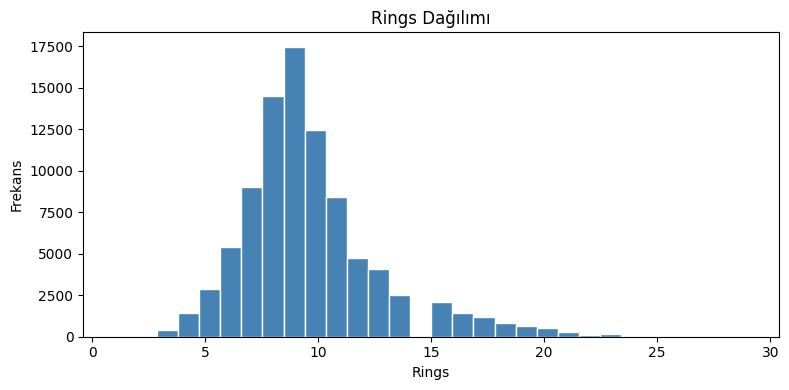

In [12]:
plt.figure(figsize=(8, 4))
plt.hist(df['Rings'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Rings Dağılımı')
plt.xlabel('Rings')
plt.ylabel('Frekans')
plt.tight_layout()
plt.show()

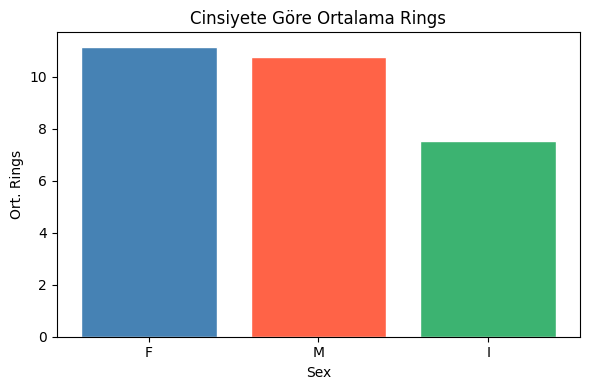

In [13]:
sex_mean = df.groupby('Sex')['Rings'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(sex_mean.index, sex_mean.values, color=['steelblue', 'tomato', 'mediumseagreen'], edgecolor='white')
plt.title('Cinsiyete Göre Ortalama Rings')
plt.xlabel('Sex')
plt.ylabel('Ort. Rings')
plt.tight_layout()
plt.show()

<Axes: >

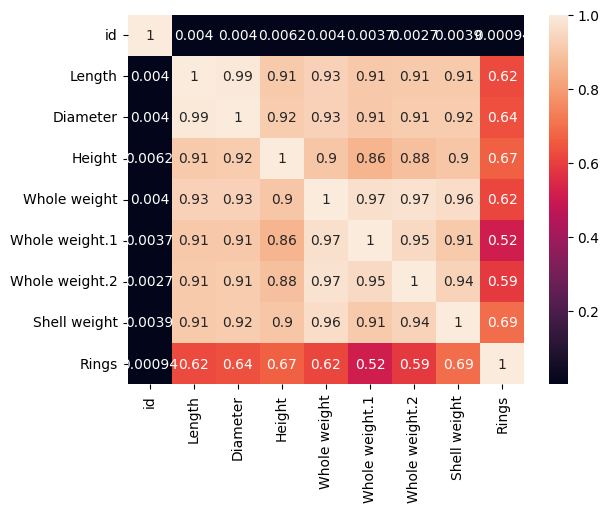

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Feature Engineering

In [15]:
df['Sex'] = df['Sex'].map({'M':0,'F':1,'I':2})

In [16]:
df['Volume'] = df['Length'] * df['Diameter'] * df['Height']

In [17]:
df['Density'] = df['Whole weight'] / (df['Volume'] + 1)

In [18]:
df['Meat_weight'] = df['Whole weight'] - df['Shell weight']

In [19]:
df['Shell_ratio'] = df['Shell weight'] / (df['Whole weight'] + 1)

In [20]:
columns = ['Shell weight','Height', 'Diameter','Volume', 'Length','Whole weight','Whole weight.2','Meat_weight','Whole weight.1', 'Sex',]

In [21]:
train = df[df['Rings'].notna()].copy()
test  = df[df['Rings'].isna()].copy()

In [40]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [22]:
x = train[columns]
y = train['Rings']

In [23]:
x_final_test = test[columns]

In [24]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90615 entries, 0 to 90614
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Shell weight    90615 non-null  float64
 1   Height          90615 non-null  float64
 2   Diameter        90615 non-null  float64
 3   Volume          90615 non-null  float64
 4   Length          90615 non-null  float64
 5   Whole weight    90615 non-null  float64
 6   Whole weight.2  90615 non-null  float64
 7   Meat_weight     90615 non-null  float64
 8   Whole weight.1  90615 non-null  float64
 9   Sex             90615 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 7.6 MB


## Model Training

In [29]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from xgboost import XGBClassifier

def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),   
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        MultinomialNB(),
        XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', verbosity=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", 
        "LogisticRegression", 
        "DecisionTreeClassifier", 
        "RandomForestClassifier", 
        "GradientBoostingClassifier", 
        "KNeighborsClassifier", 
        "AdaBoostClassifier", 
        "MultinomialNB",
        "XGBClassifier"
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)
    
    accuracy, precision, recall, f1, mdl = [], [], [], [], []
    
    print("Veriler hazır, modeller deneniyor...")
    for name, model in zip(isimler, modeller):
        print(f"{name} modeli eğitiliyor...")
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            mdl.append(model)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
        except Exception as e:
            print(f"{name} modeli çalıştırılırken hata oluştu: {e}")
            accuracy.append(np.nan)
            precision.append(np.nan)
            recall.append(np.nan)
            f1.append(np.nan)
            mdl.append(None)
    
    print("Eğitim tamamlandı.")
    
    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Model": mdl
    }, index=isimler)

    metrics_sorted = metrics.sort_values("F1", ascending=False)
    
    print("\n" + "="*80)
    print("En başarılı model:", metrics_sorted.dropna().iloc[0].name)
    print("="*80)
    
    en_iyi_model = metrics_sorted.dropna().iloc[0]["Model"]

    tahmin = en_iyi_model.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))

    print("\n" + "="*80)
    print("TÜM MODELLERİN KARŞILAŞTIRMASI")
    print("="*80)
    print(metrics_sorted.drop("Model", axis=1))

    return metrics_sorted.drop("Model", axis=1)

In [30]:
algo_test(x, y)

Veriler hazır, modeller deneniyor...
BernoulliNB modeli eğitiliyor...
LogisticRegression modeli eğitiliyor...
DecisionTreeClassifier modeli eğitiliyor...
RandomForestClassifier modeli eğitiliyor...
GradientBoostingClassifier modeli eğitiliyor...
KNeighborsClassifier modeli eğitiliyor...
AdaBoostClassifier modeli eğitiliyor...
MultinomialNB modeli eğitiliyor...
MultinomialNB modeli çalıştırılırken hata oluştu: Negative values in data passed to MultinomialNB (input X).
XGBClassifier modeli eğitiliyor...
XGBClassifier modeli çalıştırılırken hata oluştu: Invalid classes inferred from unique values of `y`.  Expected: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27], got [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25. 26. 27. 29.]
Eğitim tamamlandı.

En başarılı model: GradientBoostingClassifier

Confusion Matrix:
[[   0    0    0    0    0    0    2    2    1    1    0    0    0    0
     0    0    0

,Accuracy,Precision,Recall,F1
GradientBoostingClassifier,0.364399,0.330006,0.364399,0.337218
RandomForestClassifier,0.350163,0.328005,0.350163,0.333958
LogisticRegression,0.352260,0.298252,0.352260,0.318229
KNeighborsClassifier,0.306958,0.280662,0.306958,0.290143
DecisionTreeClassifier,0.261215,0.261830,0.261215,0.261412
AdaBoostClassifier,0.281686,0.185904,0.281686,0.193353
BernoulliNB,0.203995,0.075537,0.203995,0.106753
MultinomialNB,NaN,NaN,NaN,NaN
XGBClassifier,NaN,NaN,NaN,NaN


In [38]:
model = XGBClassifier()

In [41]:
model.fit(x, y)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [42]:
prediction =model.predict(x_final_test)

In [43]:
submission = pd.DataFrame({'id': test['id'], 'Rings': prediction})

In [44]:
submission.head()

,id,Rings
0,90615,8
1,90616,8
2,90617,8
3,90618,9
4,90619,7


In [45]:
submission.to_csv('submission.csv', index=False)